# Hierarchical and Grouped Forecasting and Reconciliation

In the lecture, we discussed the two main methods of hierarchical and grouped forecasting:

- **Single-level** — trust forecasts from **one** layer, then sum up or split down.
- **Reconciliation** — forecast **all** layers, then jointly adjust so they add up.

We started with an EDA or the Tourism Dataset, and now, we want to see a version of each of the two methods.

## Setup

In [1]:
from pathlib import Path
import os
import sys
from functools import partial

import warnings

warnings.filterwarnings("ignore")

# Nixtla long-format: keep unique_id as a column (not the index)
os.environ["NIXTLA_ID_AS_COL"] = "true"

LESSON_DIR = Path().resolve()
COURSE_DIR = LESSON_DIR.parent
DATA_DIR = COURSE_DIR / "data"

if str(COURSE_DIR) not in sys.path:
    sys.path.insert(0, str(COURSE_DIR))

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# https://nixtlaverse.nixtla.io/statsforecast/docs/models/autoets.html
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, Naive

# https://nixtlaverse.nixtla.io/hierarchicalforecast/
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.evaluation import evaluate
from hierarchicalforecast.methods import BottomUp, MinTrace
from hierarchicalforecast.utils import aggregate

# https://nixtlaverse.nixtla.io/utilsforecast/losses.html
from utilsforecast.losses import mase, scaled_crps

# https://nixtlaverse.nixtla.io/utilsforecast/plotting.html
from utilsforecast.plotting import plot_series

# https://seaborn.pydata.org/
sns.set_theme(style="whitegrid")

from utils import load_tourism

In [3]:
def rename_models(df, labels):
    """Apply at most one string replacement to each column name.

    Reconciled columns look like ``AutoETS/MinTrace_method-mint_shrink``;
    short labels keep legends readable.
    """
    return df.rename(
        columns=lambda c: next(
            (c.replace(k, v) for k, v in labels.items() if k in c),
            c,
        )
    )

## Forecasting Australian domestic tourism

A vast amount of time series datasets are organized into structures with different levels or hierarchies of aggregation. Examples include:

1. cross-sectional aggregations such as categories, brands, or
2. geographical groupings, or
3. temporal aggregations such as weeks, months or years

_Coherent_ forecasts across levels are necessary for consistent decision-making and planning.

**Workflow:**

1. `aggregate(spec=...)`; to get the series at all levels.
2. Hold out 2016–2017 (8 quarters) as the test set
3. _BaseForecasts_: Fit a model for every series.
4. Reconcile with: `BottomUp` and `MinT`
5. Evaluate each method using metrics

### Load and reshape tourism

In [4]:
tourism = load_tourism().reset_index()
tourism.head()

state_abbrev = {
    "Australian Capital Territory": "ACT",
    "New South Wales": "NSW",
    "Northern Territory": "NT",
    "Queensland": "QLD",
    "South Australia": "SA",
    "Tasmania": "TAS",
    "Victoria": "VIC",
    "Western Australia": "WA",
}

aus_tourism = tourism.assign(
    Country="Australia",
    State=lambda x: x["State"].replace(state_abbrev),
    ds=lambda x: x["Quarter"].dt.to_timestamp(),
    y=lambda x: x["Trips"],
)[["Country", "State", "Region", "Purpose", "ds", "y"]]

aus_tourism

,Country,State,Region,Purpose,ds,y
0,Australia,SA,Adelaide,Business,1998-01-01,135.077690
1,Australia,SA,Adelaide,Business,1998-04-01,109.987316
2,Australia,SA,Adelaide,Business,1998-07-01,166.034687
3,Australia,SA,Adelaide,Business,1998-10-01,127.160464
4,Australia,SA,Adelaide,Business,1999-01-01,137.448533
...,...,...,...,...,...,...
24315,Australia,SA,Yorke Peninsula,Visiting,2016-10-01,33.672151
24316,Australia,SA,Yorke Peninsula,Visiting,2017-01-01,46.223014
24317,Australia,SA,Yorke Peninsula,Visiting,2017-04-01,50.582837
24318,Australia,SA,Yorke Peninsula,Visiting,2017-07-01,27.766728


### Aggregate, split, forecast, reconcile

#### 1. Build the mixed hierarchy with `aggregate()`

Nested geography crossed with Purpose → many parallel roll-up paths.


In [5]:
# Mixed structure: nested geography crossed with Purpose
tourism_spec = [
    ["Country"],
    ["Country", "State"],
    ["Country", "Purpose"],
    ["Country", "State", "Region"],
    ["Country", "State", "Purpose"],
    ["Country", "State", "Region", "Purpose"],
]

Y_df, S_df, tags = aggregate(
    df=aus_tourism,
    spec=tourism_spec,
)

# Long panel: every series at every level
display(Y_df)

,unique_id,ds,y
0,Australia,1998-01-01,23182.197269
1,Australia,1998-04-01,20323.380067
2,Australia,1998-07-01,19826.640511
3,Australia,1998-10-01,20830.129891
4,Australia,1999-01-01,22087.353380
...,...,...,...
33995,Australia/WA/Experience Perth/Visiting,2016-10-01,439.699451
33996,Australia/WA/Experience Perth/Visiting,2017-01-01,356.867038
33997,Australia/WA/Experience Perth/Visiting,2017-04-01,302.296119
33998,Australia/WA/Experience Perth/Visiting,2017-07-01,373.442070


In [6]:
print(f"Number of series: {Y_df['unique_id'].nunique()}")

Number of series: 425


In [7]:
# Summing matrix: which bottom series add into each upper series
display(S_df)
print(f"S_df shape: {S_df.shape}  (rows=all series, cols=bottom series)")

,unique_id,Australia/ACT/Canberra/Business,Australia/ACT/Canberra/Holiday,Australia/ACT/Canberra/Other,Australia/ACT/Canberra/Visiting,Australia/NSW/Blue Mountains/Business,Australia/NSW/Blue Mountains/Holiday,Australia/NSW/Blue Mountains/Other,Australia/NSW/Blue Mountains/Visiting,Australia/NSW/Capital Country/Business,...,Australia/WA/Australia's North West/Other,Australia/WA/Australia's North West/Visiting,Australia/WA/Australia's South West/Business,Australia/WA/Australia's South West/Holiday,Australia/WA/Australia's South West/Other,Australia/WA/Australia's South West/Visiting,Australia/WA/Experience Perth/Business,Australia/WA/Experience Perth/Holiday,Australia/WA/Experience Perth/Other,Australia/WA/Experience Perth/Visiting
0,Australia,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,Australia/ACT,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Australia/NSW,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Australia/NT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Australia/QLD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420,Australia/WA/Australia's South West/Visiting,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
421,Australia/WA/Experience Perth/Business,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
422,Australia/WA/Experience Perth/Holiday,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
423,Australia/WA/Experience Perth/Other,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


S_df shape: (425, 305)  (rows=all series, cols=bottom series)


In [8]:
# tags: level name → list of unique_ids at that level
pd.Series({k: len(v) for k, v in tags.items()}, name="n_series")


Country                           1
Country/State                     8
Country/Purpose                   4
Country/State/Region             76
Country/State/Purpose            32
Country/State/Region/Purpose    304
Name: n_series, dtype: int64

#### 2. Hold out the test window

Final two years (8 quarters, 2016–2017) for evaluation.


```mermaid
graph LR
    A("Y_df (Full Dataset)"):::mainData -->|"ds < '2016'"| B("Y_train_df (Training Set)"):::trainData
    A -->|"ds >= '2016'"| C("Y_test_df (Testing Set)"):::testData
```

In [9]:
Y_train_df = Y_df.loc[Y_df["ds"] < "2016"]
Y_test_df = Y_df.loc[Y_df["ds"] >= "2016"]

print(
    f"train rows: {len(Y_train_df):,}  |  test rows: {len(Y_test_df):,}\n"
    f"train ds: {Y_train_df['ds'].min().date()} → {Y_train_df['ds'].max().date()}\n"
    f"test  ds: {Y_test_df['ds'].min().date()} → {Y_test_df['ds'].max().date()}"
)
display(Y_test_df.head())


train rows: 30,600  |  test rows: 3,400
train ds: 1998-01-01 → 2015-10-01
test  ds: 2016-01-01 → 2017-10-01


,unique_id,ds,y
72,Australia,2016-01-01,26660.637689
73,Australia,2016-04-01,24285.027757
74,Australia,2016-07-01,24191.320131
75,Australia,2016-10-01,26347.600973
76,Australia,2017-01-01,27496.389021


#### 3. Base forecasts at every level

`fitted=True` is required so MinTrace can estimate residual covariances from in-sample fits.


In [10]:
sf = StatsForecast(
    models=[AutoETS(season_length=4), Naive()],
    freq="QS",  # freq="QS" → quarter-start timestamps
    n_jobs=-1,  # use all available CPU cores
)

Y_hat_df = sf.forecast(
    h=8,           # 8-quarter horizon (= test length)
    df=Y_train_df,
    fitted=True,   # keep in-sample fits for MinTrace
)
display(Y_hat_df)


,unique_id,ds,AutoETS,Naive
0,Australia,2016-01-01,26293.731209,25140.161221
1,Australia,2016-04-01,24465.684711,25140.161221
2,Australia,2016-07-01,23870.122954,25140.161221
3,Australia,2016-10-01,24591.404841,25140.161221
4,Australia,2017-01-01,26293.731209,25140.161221
...,...,...,...,...
3395,Australia/WA/Visiting,2016-10-01,755.678719,758.813298
3396,Australia/WA/Visiting,2017-01-01,767.345916,758.813298
3397,Australia/WA/Visiting,2017-04-01,726.788515,758.813298
3398,Australia/WA/Visiting,2017-07-01,691.291353,758.813298


In [11]:
# In-sample fitted values (same unique_ids as training history)
Y_fitted_df = sf.forecast_fitted_values()
display(Y_fitted_df)


,unique_id,ds,y,AutoETS,Naive
0,Australia,1998-01-01,23182.197269,22592.021503,NaN
1,Australia,1998-04-01,20323.380067,21314.497292,23182.197269
2,Australia,1998-07-01,19826.640511,20279.433321,20323.380067
3,Australia,1998-10-01,20830.129891,20643.218953,19826.640511
4,Australia,1999-01-01,22087.353380,22178.986881,20830.129891
...,...,...,...,...,...
30595,Australia/WA/Visiting,2014-10-01,734.414572,748.402134,705.119524
30596,Australia/WA/Visiting,2015-01-01,878.514801,753.206886,734.414572
30597,Australia/WA/Visiting,2015-04-01,655.365295,774.031221,878.514801
30598,Australia/WA/Visiting,2015-07-01,696.480293,680.415592,655.365295


#### 4. Reconcile base forecasts

Classic reconciliation methods:

- `BottomUp()` — Simple addition to the upper levels.
- `TopDown()` — Simple addition to the upper levels.

Alternative reconciliation methods:

- `MiddleOut`: It anchors the base predictions in a middle level. The levels above the base predictions use the bottom-up approach, while the levels below use a top-down.
- `MinTrace`: Minimizes the total forecast variance of the space of coherent forecasts, with the Minimum Trace reconciliation.
    - `method="ols"` — equal weight across levels.
    - **`method="mint_shrink"` — shrink residual covariances (what we prefer in practice)**.

The code below will do multiple hierarchical methods in parallel; producing forecasts for each method, and they are all based on the _Base Forecasts_ predicted by the _model_. Illustrated with the figure below:

```mermaid
graph LR
    A("Model") --> B("Base Forecasts")
    B --> C1
    B --> C2
    B --> C3
    B --> C4
     subgraph "Reconciliation method"
         C1("Mint Shrink")
         C2("OLS")
         C3("Bottom Up")
         C4("...")
     end
    C1 --> D1("Forecasts")
    C2 --> D2("Forecasts")
    C3 --> D3("Forecasts")
    C4 --> D4("...")
```

Thankfully, with enough compute power, we can experiment with various methods for forecasting in a very short amount of time (seconds to minutes-- depending on dataset size); to select which one optimizes our metric on our data.

In [12]:
reconcilers = [
    BottomUp(),
    MinTrace(method="ols"),
    MinTrace(method="mint_shrink"),
]

hrec = HierarchicalReconciliation(reconcilers=reconcilers)
Y_rec_df = hrec.reconcile(
    Y_hat_df=Y_hat_df,  # base forecasts (horizon)
    Y_df=Y_fitted_df,  # fitted values → residuals for MinTrace
    S_df=S_df,  # summing matrix from aggregate()
    tags=tags,  # which ids sit at each level
)

# Short labels for legends / evaluation tables
tourism_renames = {
    "AutoETS/MinTrace_method-mint_shrink": "MinT",
    "AutoETS/MinTrace_method-ols": "OLS",
    "AutoETS/BottomUp": "BottomUp",
    "AutoETS": "Base",
}
Y_rec_df = rename_models(Y_rec_df, tourism_renames)
list(Y_rec_df.columns)


['unique_id',
 'ds',
 'Base',
 'Naive',
 'BottomUp',
 'Naive/BottomUp',
 'OLS',
 'Naive/MinTrace_method-ols',
 'MinT',
 'Naive/MinTrace_method-mint_shrink']

In [13]:
# Point forecasts (trips, '000) for each series × quarter × method
display(Y_rec_df)


,unique_id,ds,Base,Naive,BottomUp,Naive/BottomUp,OLS,Naive/MinTrace_method-ols,MinT,Naive/MinTrace_method-mint_shrink
0,Australia,2016-01-01,26293.731209,25140.161221,24681.663762,25140.161222,26179.227026,25140.161221,25668.806779,25140.161222
1,Australia,2016-04-01,24465.684711,25140.161221,22949.801904,25140.161222,24371.211278,25140.161221,23982.055297,25140.161222
2,Australia,2016-07-01,23870.122954,25140.161221,22418.484671,25140.161222,23776.918680,25140.161221,23462.684029,25140.161222
3,Australia,2016-10-01,24591.404841,25140.161221,23058.257520,25140.161222,24503.914009,25140.161221,24157.092110,25140.161222
4,Australia,2017-01-01,26293.731209,25140.161221,24801.654393,25140.161222,26192.617120,25140.161221,25833.968989,25140.161222
...,...,...,...,...,...,...,...,...,...,...
3395,Australia/WA/Experience Perth/Visiting,2016-10-01,414.555551,406.907362,414.555551,406.907362,425.236851,406.907363,425.258728,406.907362
3396,Australia/WA/Experience Perth/Visiting,2017-01-01,424.775101,406.907362,424.775101,406.907362,440.273657,406.907363,442.837329,406.907362
3397,Australia/WA/Experience Perth/Visiting,2017-04-01,401.802051,406.907362,401.802051,406.907362,408.112652,406.907363,408.095526,406.907362
3398,Australia/WA/Experience Perth/Visiting,2017-07-01,388.653891,406.907362,388.653891,406.907362,395.152825,406.907363,394.667778,406.907362


### Forecast plots: national and states

Recent history via `max_insample_length=20` (~2011 onward). Point forecasts — no intervals yet.


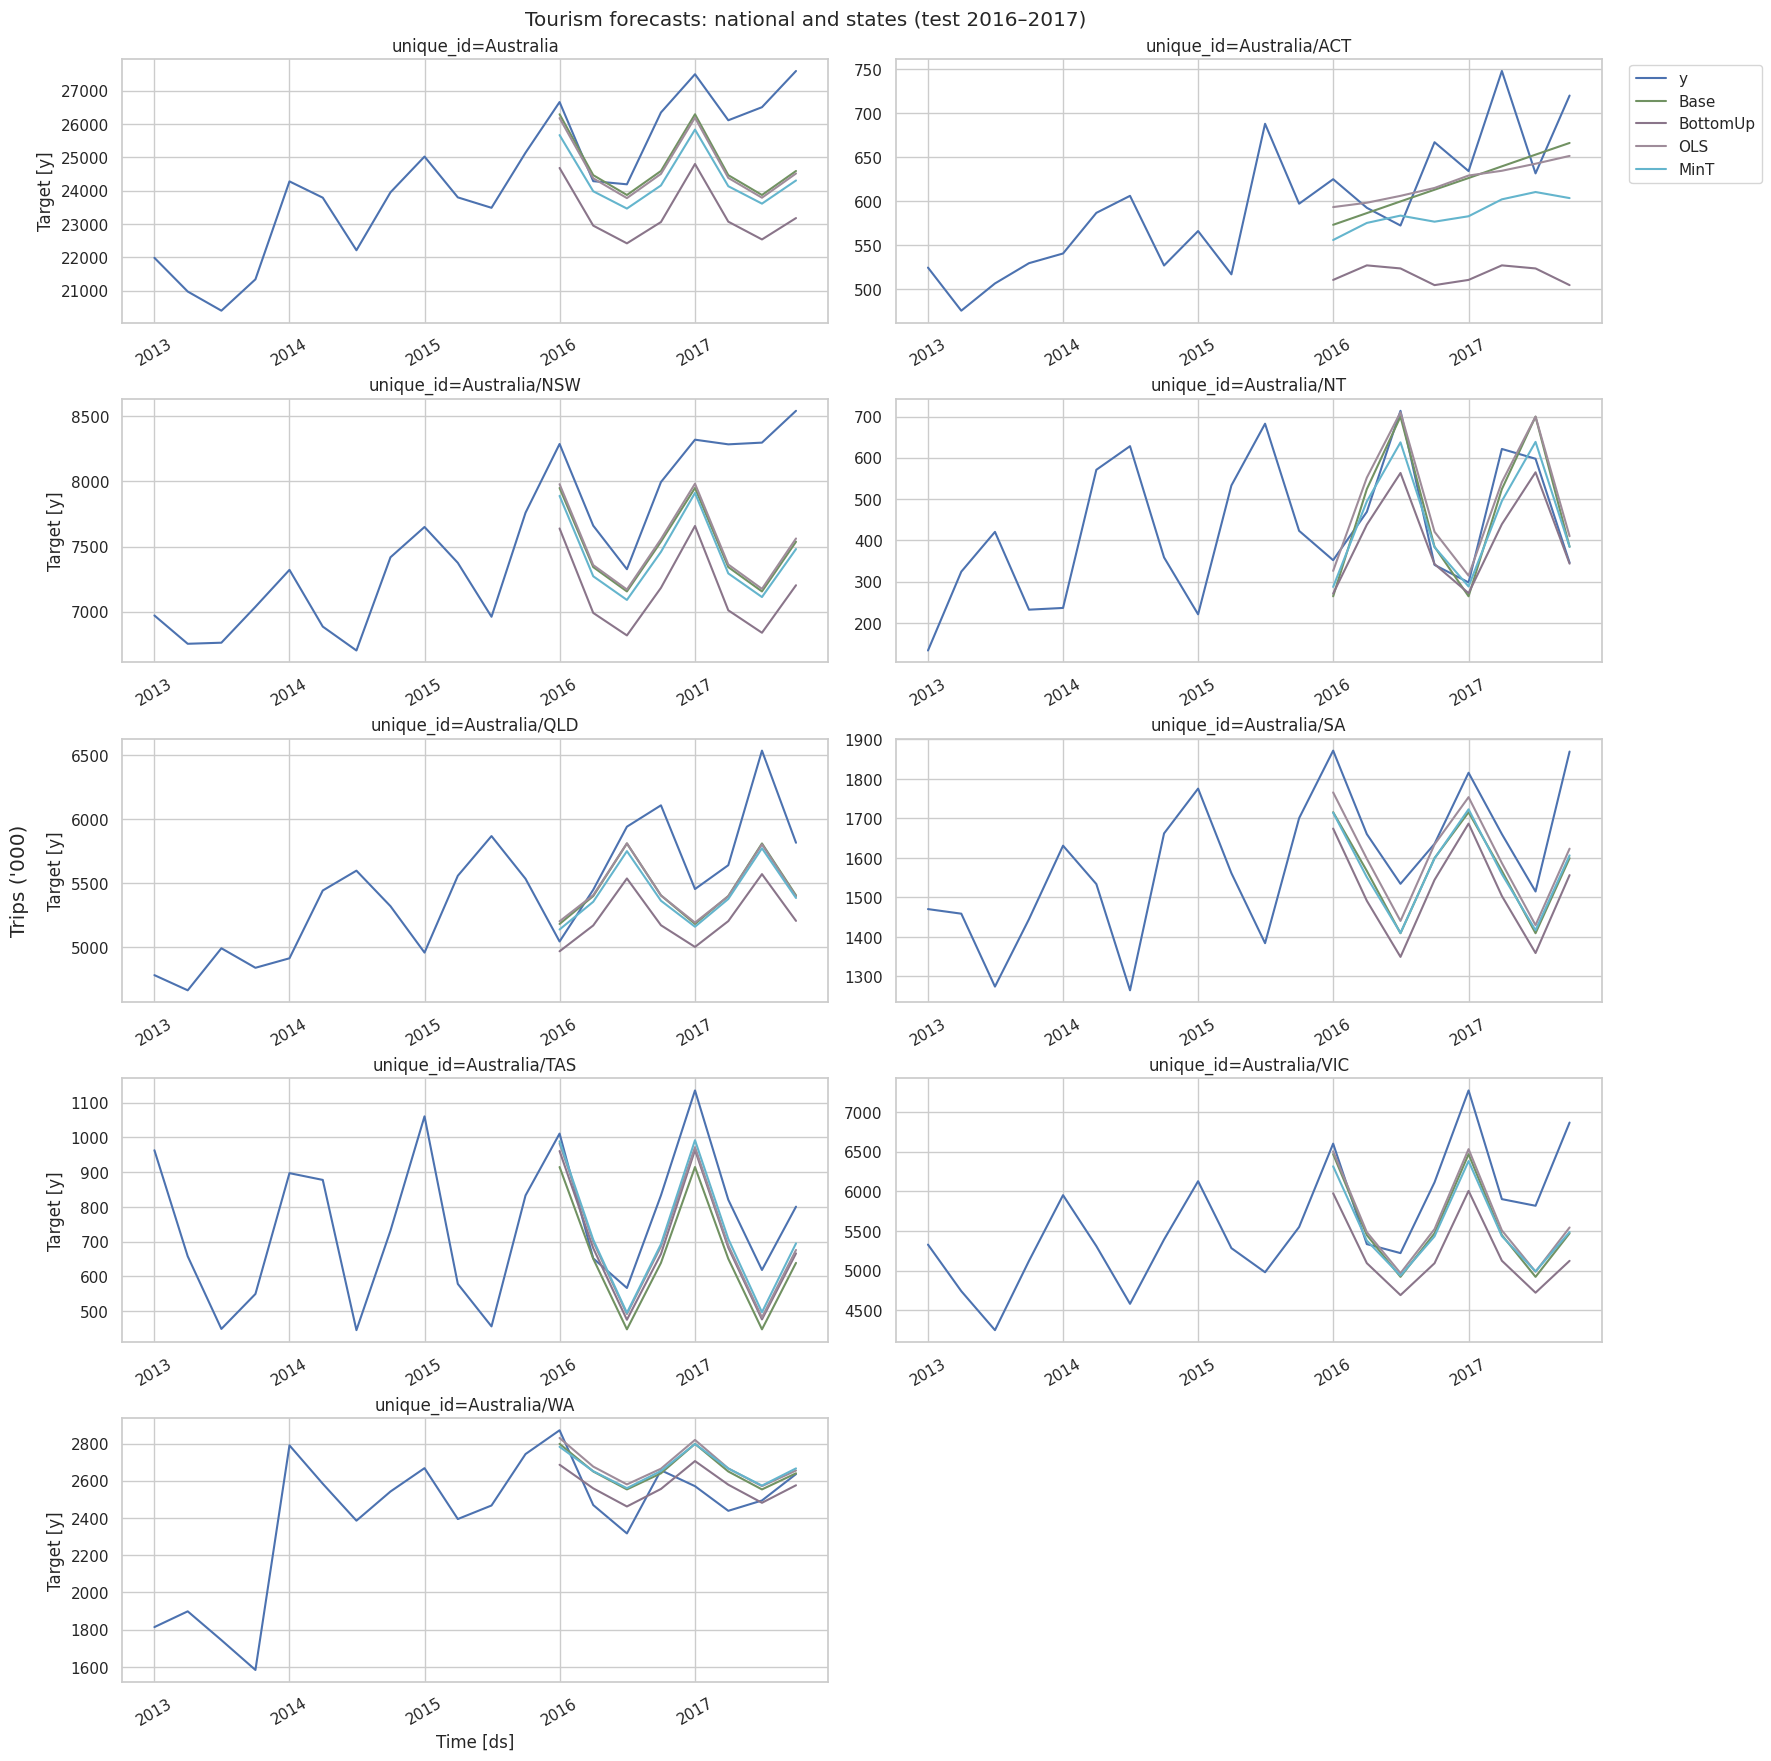

In [14]:
plot_ids = [*tags["Country"], *tags["Country/State"]]

# https://nixtlaverse.nixtla.io/utilsforecast/plotting.html
fig = plot_series(
    df=Y_df,
    forecasts_df=Y_rec_df,
    ids=plot_ids,
    models=["Base", "BottomUp", "OLS", "MinT"],
    # ~2011 onward when train ends in 2015 (quarterly)
    max_insample_length=20,
    plot_random=False,
    max_ids=len(plot_ids),
    engine="matplotlib",
)
fig.suptitle("Tourism forecasts: national and states (test 2016–2017)")
fig.supylabel("Trips ('000)")
fig


### Forecast plots: by purpose of travel

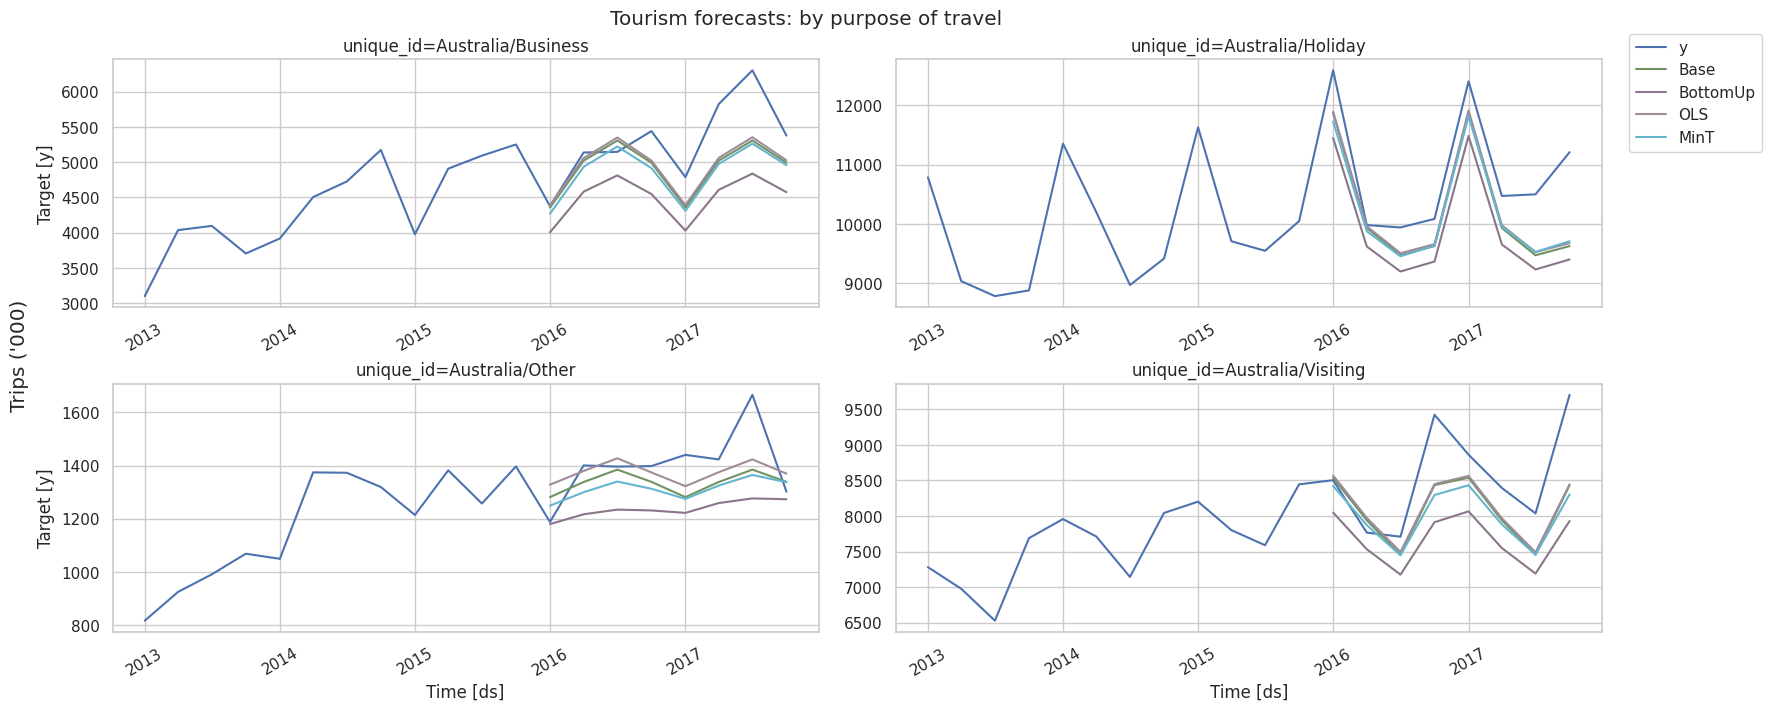

In [15]:
purpose_ids = list(tags["Country/Purpose"])

fig = plot_series(
    df=Y_df,
    forecasts_df=Y_rec_df,
    ids=purpose_ids,
    models=["Base", "BottomUp", "OLS", "MinT"],
    max_insample_length=20,
    plot_random=False,
    max_ids=len(purpose_ids),
    engine="matplotlib",
)
fig.suptitle("Tourism forecasts: by purpose of travel")
fig.supylabel("Trips ('000)")
fig


## Reconciled distributional forecasts

- So far we reconciled **point forecasts**.
- **Prediction intervals** need reconciled _distributions_

The `intervals_method` to pick depends on the model used to produce the forecasts:

1. `normality` (default) — if **base forecasts** are Normally distributed, reconciled forecasts stay Normal, and we get cheap and fast computation.
2. `bootstrap` — if normality is unknown, we use Bootstrapping, which is a bit heavier in compute.

### Forecast with interval levels

In [16]:
# Re-forecast tourism with prediction levels for the distributional demo
pi_levels = [80, 90]

Y_hat_pi = sf.forecast(
    h=8,
    df=Y_train_df,
    fitted=True,
    # level → also emit lo/hi columns around each point forecast
    level=pi_levels,
)

Y_fitted_pi = sf.forecast_fitted_values()

# One reconciler so column names stay simple for the comparison plot
hrec_mint = HierarchicalReconciliation(
    reconcilers=[MinTrace(method="mint_shrink")]
)

# Assumes Normal distribution
Y_rec_norm = hrec_mint.reconcile(
    Y_hat_df=Y_hat_pi,
    Y_df=Y_fitted_pi,
    S_df=S_df,
    tags=tags,
    level=pi_levels,
    intervals_method="normality",
)

# Doesn't assume Normal distribution
Y_rec_boot = hrec_mint.reconcile(
    Y_hat_df=Y_hat_pi,
    Y_df=Y_fitted_pi,
    S_df=S_df,
    tags=tags,
    level=pi_levels,
    intervals_method="bootstrap",
)

# Compare 90% intervals for the national total under both methods
total_id = tags["Country"][0]
pi_renames = {
    "AutoETS/MinTrace_method-mint_shrink": "MinT",
    "AutoETS": "Base",
}
Y_rec_norm = rename_models(Y_rec_norm, pi_renames)
Y_rec_boot = rename_models(Y_rec_boot, pi_renames)

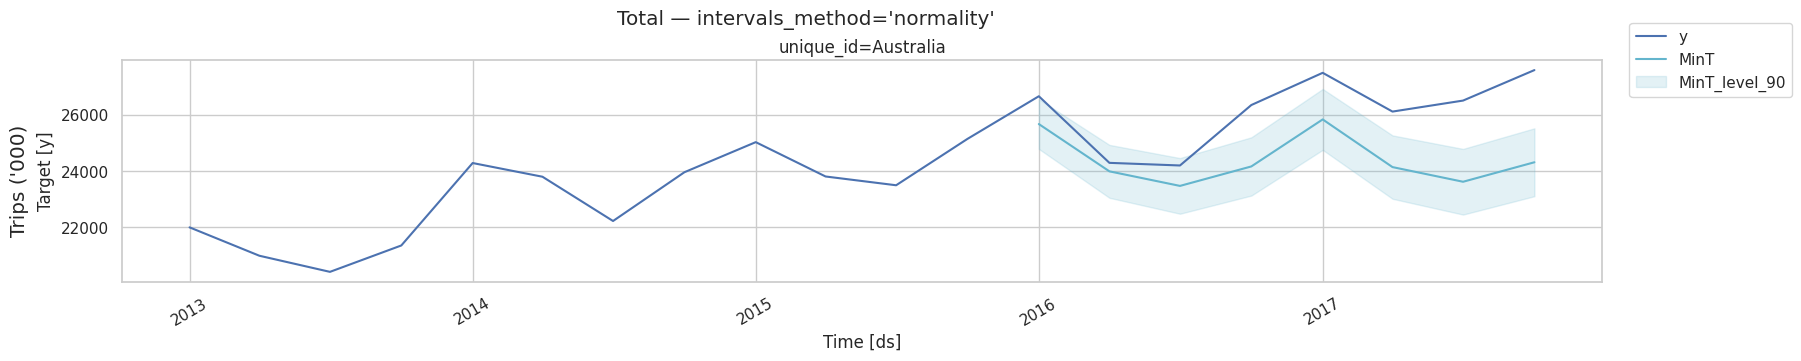

In [17]:
label, rec_df = "normality", Y_rec_norm
fig = plot_series(
    df=Y_df,
    forecasts_df=rec_df,
    ids=[total_id],
    models=["MinT"],
    level=[90],
    max_insample_length=20,
    engine="matplotlib",
)
fig.suptitle(f"Total — intervals_method={label!r}")
fig.supylabel("Trips ('000)")
fig

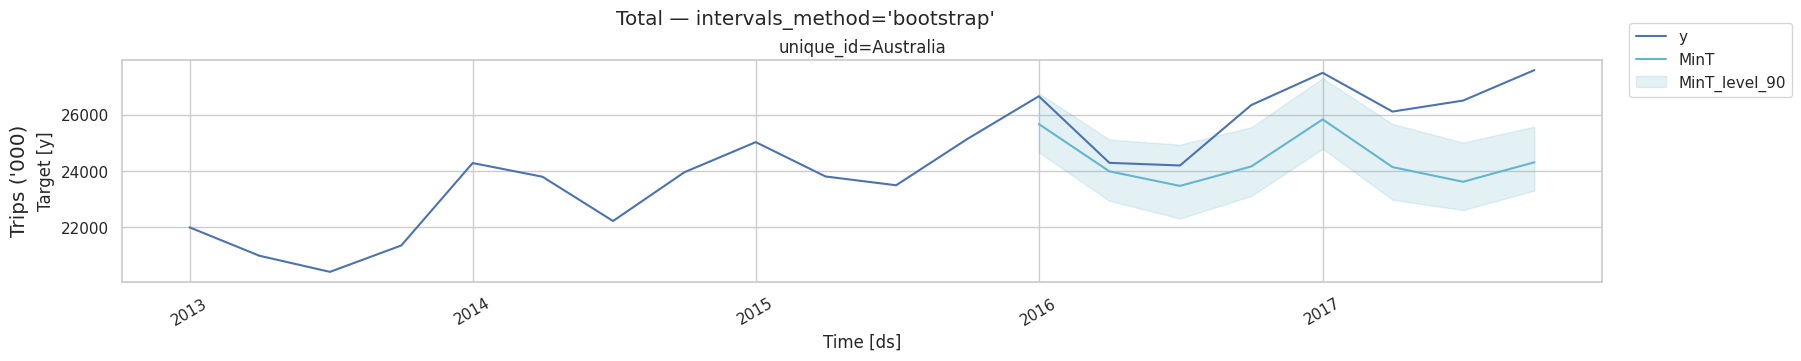

In [18]:
label, rec_df = "bootstrap", Y_rec_boot
fig = plot_series(
    df=Y_df,
    forecasts_df=rec_df,
    ids=[total_id],
    models=["MinT"],
    level=[90],
    max_insample_length=20,
    engine="matplotlib",
)
fig.suptitle(f"Total — intervals_method={label!r}")
fig.supylabel("Trips ('000)")
fig

### Accuracy by level (MASE and CRPS skill score)

Let's compare scaled point and distributional accuracy across the hierarchy.

We will use two evaluation metrics:

1. `MASE` gives a scaled measure of **point-forecast accuracy**, using the seasonal naive benchmark from the training data. Lower values are better.
2. `Skill Score (CRPS)` gives a scaled measure of **distributional accuracy** by comparing each method's `scaled_crps` against the unreconciled `Naive` forecast. Higher values are better, and values above `0` beat `Naive`.


In [19]:
# Which unique_ids belong to each reporting level?
eval_tags = {
    "Total": tags["Country"],
    "Purpose": tags["Country/Purpose"],
    "State": tags["Country/State"],
    "Regions": tags["Country/State/Region"],
    "Bottom": tags["Country/State/Region/Purpose"],
}

# Use many central intervals so scaled CRPS can approximate
# the full predictive distribution well.
# Start at 2 rather than 0; including level=0 produces invalid
# reconciled interval columns for this workflow.
crps_levels = list(range(2, 100, 2))

Y_hat_eval = sf.forecast(
    h=8,
    df=Y_train_df,
    fitted=True,
    level=crps_levels,
)
Y_fitted_eval = sf.forecast_fitted_values()

Y_rec_eval = hrec.reconcile(
    Y_hat_df=Y_hat_eval,
    Y_df=Y_fitted_eval,
    S_df=S_df,
    tags=tags,
    level=crps_levels,
    intervals_method="normality",
)

eval_renames = {
    "AutoETS/MinTrace_method-mint_shrink": "AutoETS/MinT",
    "AutoETS/MinTrace_method-ols": "AutoETS/OLS",
    "AutoETS/BottomUp": "AutoETS/BottomUp",
}
Y_rec_eval = rename_models(Y_rec_eval, eval_renames)

# Attach actuals `y` from the test window
# and keep the Naive benchmark for the CRPS skill score.
eval_df = Y_rec_eval.merge(Y_test_df, on=["unique_id", "ds"])
display(eval_df)

,unique_id,ds,AutoETS,AutoETS-lo-98,AutoETS-lo-96,AutoETS-lo-94,AutoETS-lo-92,AutoETS-lo-90,AutoETS-lo-88,AutoETS-lo-86,...,Naive/MinTrace_method-mint_shrink-hi-82,Naive/MinTrace_method-mint_shrink-hi-84,Naive/MinTrace_method-mint_shrink-hi-86,Naive/MinTrace_method-mint_shrink-hi-88,Naive/MinTrace_method-mint_shrink-hi-90,Naive/MinTrace_method-mint_shrink-hi-92,Naive/MinTrace_method-mint_shrink-hi-94,Naive/MinTrace_method-mint_shrink-hi-96,Naive/MinTrace_method-mint_shrink-hi-98,y
0,Australia,2016-01-01,26293.731209,23770.261465,24065.958959,24253.569539,24394.701670,24509.501771,24607.214688,24692.889800,...,26858.505940,26940.935587,27031.571401,27132.797406,27248.246197,27383.883668,27550.632696,27772.296477,28121.666032,26660.637689
1,Australia,2016-04-01,24465.684711,21647.641039,21977.856392,22187.367446,22344.974451,22473.175591,22582.294897,22677.971182,...,27570.267627,27686.840751,27815.019149,27958.174338,28121.443584,28313.263935,28549.082672,28862.562598,29356.645761,24285.027757
2,Australia,2016-07-01,23870.122954,20797.681866,21157.707236,21386.131791,21557.966686,21697.741117,21816.711111,21921.024522,...,28116.421579,28259.193915,28416.179750,28591.508334,28791.471506,29026.402496,29315.220285,29699.153217,30304.279036,24191.320131
3,Australia,2016-10-01,24591.404841,21270.091936,21659.279841,21906.207089,22091.960839,22243.057185,22371.663907,22484.426843,...,28576.850658,28741.709952,28922.981580,29125.433590,29356.331172,29627.606114,29961.104170,30404.431733,31103.170842,26347.600973
4,Australia,2017-01-01,26293.731209,22708.784646,23128.864862,23395.392290,23595.890493,23758.980314,23897.795366,24019.509011,...,28982.496820,29166.815114,29369.482956,29595.831184,29853.982529,30157.277134,30530.139296,31025.794579,31807.008653,27496.389021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3395,Australia/WA/Experience Perth/Visiting,2016-10-01,414.555551,218.748345,241.692825,256.250362,267.201429,276.109278,283.691257,290.339169,...,561.008131,568.400403,576.528603,585.606528,595.959950,608.123888,623.077903,642.956661,674.288045,439.699451
3396,Australia/WA/Experience Perth/Visiting,2017-01-01,424.775101,214.289536,238.954010,254.602828,266.374824,275.950435,284.100784,291.247045,...,579.197260,587.462071,596.549674,606.699104,618.274581,631.874277,648.593374,670.818502,705.848053,356.867038
3397,Australia/WA/Experience Perth/Visiting,2017-04-01,401.802051,186.113111,211.387311,227.422980,239.485990,249.298318,257.650150,264.973072,...,595.641489,604.695136,614.650107,625.768249,638.448549,653.346270,671.661124,696.007531,734.380482,302.296119
3398,Australia/WA/Experience Perth/Visiting,2017-07-01,388.653891,166.175789,192.245536,208.785954,221.228667,231.349853,239.964573,247.517997,...,610.763518,620.542575,631.295172,643.304139,657.000428,673.091805,692.874108,719.171234,760.618758,373.442070


In [20]:
eval_models = [
    "Naive",
    "AutoETS",
    "AutoETS/BottomUp",
    "AutoETS/MinT",
    "AutoETS/OLS",
]

evaluation = evaluate(
    df=eval_df,
    tags=eval_tags,
    train_df=Y_train_df,
    metrics=[
        partial(mase, seasonality=4),
        scaled_crps,
    ],
    models=eval_models,
    level=crps_levels,
)
# Long format: one row per level × metric × (model columns)
display(evaluation)

,level,metric,Naive,AutoETS,AutoETS/BottomUp,AutoETS/MinT,AutoETS/OLS
0,Total,mase,1.604440,1.526529,3.090759,1.928301,1.600741
1,Total,scaled_crps,0.039011,0.036361,0.098382,0.054996,0.040671
2,Purpose,mase,1.451873,1.298465,2.174100,1.406058,1.222652
3,Purpose,scaled_crps,0.069701,0.048202,0.096055,0.056054,0.050386
4,State,mase,1.627188,1.307143,1.853553,1.317694,1.191397
5,State,scaled_crps,0.103919,0.063751,0.098279,0.065902,0.060083
6,Regions,mase,1.425065,1.109939,1.175749,0.993542,0.992330
7,Regions,scaled_crps,0.196399,0.127918,0.134898,0.116515,0.116115
8,Bottom,mase,1.328216,0.986415,0.986415,0.937247,1.019831
9,Bottom,scaled_crps,0.605825,0.345864,0.345864,0.338999,0.753455


Let's reshape the results into a table of scaled point and distributional accuracy:

In [21]:
comparison_models = [
    "AutoETS",
    "AutoETS/BottomUp",
    "AutoETS/MinT",
    "AutoETS/OLS",
]
model_labels = {
    "AutoETS": "Base",
    "AutoETS/BottomUp": "BottomUp",
    "AutoETS/MinT": "MinT",
    "AutoETS/OLS": "OLS",
}

evaluation_table = (
    evaluation.pivot_table(
        index="level",
        columns="metric",
        values=eval_models,
        sort=False,
    )
    .rename(index={"Overall": "All series"})
    .reorder_levels([1, 0], axis="columns")
    .sort_index(axis="columns")
)

crps_table = evaluation_table["scaled_crps"]
crps_skill_score = 100 * (
    crps_table["Naive"].to_numpy()[:, None]
    - crps_table[comparison_models].to_numpy()
) / crps_table["Naive"].to_numpy()[:, None]

crps_skill_score = pd.DataFrame(
    crps_skill_score,
    index=evaluation_table.index,
    columns=[model_labels[name] for name in comparison_models],
)

mase_table = evaluation_table["mase"][comparison_models].rename(columns=model_labels)

evaluation_final = pd.concat(
    {
        "MASE": mase_table,
        "Skill Score (CRPS)": crps_skill_score,
    },
    axis="columns",
).reorder_levels([1, 0], axis="columns").sort_index(axis="columns")

display(evaluation_final.round(2))


Base                    BottomUp                     MinT  \
            MASE Skill Score (CRPS)     MASE Skill Score (CRPS)  MASE   
level                                                                   
Total       1.53               6.79     3.09            -152.19  1.93   
Purpose     1.30              30.85     2.17             -37.81  1.41   
State       1.31              38.65     1.85               5.43  1.32   
Regions     1.11              34.87     1.18              31.31  0.99   
Bottom      0.99              42.91     0.99              42.91  0.94   
All series  1.02              42.27     1.06              41.74  0.96   

                                OLS                     
           Skill Score (CRPS)  MASE Skill Score (CRPS)  
level                                                   
Total                  -40.98  1.60              -4.26  
Purpose                 19.58  1.22              27.71  
State                   36.58  1.19              42.18  
Regions                 40.67  0.99              40.88  
Bottom                  44.04  1.02             -24.37  
All series              43.71  1.02             -19.15

How to read the evaluation results table:

1. `MASE`: Lower is better.
2. `Skill Score (CRPS)` Higher is better.

- We use scaled measures because the number of trips varies a lot across the hierarchy.
- Each row pools the corresponding level of the hierarchy:
  - `Total`: the national series (`Australia`)
  - `Purpose`: the 4 purpose aggregates
  - `State`: the 8 state aggregates
  - `Regions`: the 76 regional series
  - `Bottom`: the 304 finest-level series
  - `All series`: every series pooled together

Because these metrics are scaled, we can compare methods fairly even though the total and bottom-level series live on very different magnitudes.

A good reconciliation method should:

- push `MASE` down relative to the base forecasts, and
- push the `CRPS` skill score up relative to the other methods.

When `MinT` does both, it is using information from across the hierarchy to improve both point forecasts and predictive distributions.